In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import psycopg2
import time
from matplotlib.patheffects import withStroke


# --- Thông tin kết nối ---
conn = psycopg2.connect(
    host="localhost",          # hoặc IP server
    port="5432",
    database="postgres",
    user="postgres",
    password="00000"
)

In [32]:
import psycopg2
import pandas as pd


def get_data():
    try:
        # Kết nối database
        conn = psycopg2.connect(
            host="localhost",
            port="5432",
            database="postgres",   # ⚠ kiểm tra đúng DB chưa
            user="postgres",
            password="00000"
        )

        print("✅ Connected to database")

        # Test bảng có tồn tại không
        test_query = "SELECT * FROM base_order;"
        count = pd.read_sql(test_query, conn).iloc[0, 0]
        print(f"📦 Total rows in base_order: {count}")

        if count == 0:
            print("⚠️ Bảng tồn tại nhưng không có dữ liệu")

        # Lấy dữ liệu (giới hạn 1000 dòng để test trước)
        query = "SELECT * FROM base_order ;"
        df = pd.read_sql(query, conn)

        conn.close()
        print("🔒 Connection closed")

        return df

    except Exception as e:
        print("❌ ERROR:", e)
        return None


# ===== RUN =====
df = get_data()

df


✅ Connected to database


C:\Users\TFS-MT-051\AppData\Local\Temp\ipykernel_80172\357071048.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  count = pd.read_sql(test_query, conn).iloc[0, 0]


📦 Total rows in base_order: e22acc9c116caa3f2b7121bbb380d08e


C:\Users\TFS-MT-051\AppData\Local\Temp\ipykernel_80172\357071048.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


🔒 Connection closed


,order_id,order_status,order_purchase_date,delivered_date,customer_id,customer_unique_id,customer_city,customer_state,customer_lat,customer_lng,...,product_length_cm,product_height_cm,product_width_cm,seller_city,seller_state,product_category_name_english,payment_installments,payment_value,avg_review_score,customer_type
0,e22acc9c116caa3f2b7121bbb380d08e,delivered,2018-05-10,2018-05-16,fadbb3709178fc513abc1b2670aa1ad2,0000366f3b9a7992bf8c76cfdf3221e2,cajamar,SP,-23.340235,-46.830140,...,34.0,7.0,32.0,piracicaba,SP,bed_bath_table,8.0,141.90,NaN,New
1,3594e05a005ac4d06a72673270ef9ec9,delivered,2018-05-07,2018-05-10,4cb282e167ae9234755102258dd52ee8,0000b849f77a49e4a4ce2b2a4ca5be3f,osasco,SP,-23.559115,-46.787626,...,26.0,11.0,18.0,sao paulo,SP,health_beauty,1.0,27.19,NaN,New
2,b33ec3b699337181488304f362a6b734,delivered,2017-03-10,2017-04-05,9b3932a6253894a02c1df9d19004239f,0000f46a3911fa3c0805444483337064,sao jose,SC,-27.542880,-48.633426,...,25.0,50.0,35.0,campo limpo paulista,SP,stationery,8.0,86.22,NaN,New
3,41272756ecddd9a9ed0180413cc22fb6,delivered,2017-10-12,2017-11-01,914991f0c02ef0843c0e7010c819d642,0000f6ccb0745a6a4b88665a16c9f078,belem,PA,-1.312214,-48.483158,...,19.0,5.0,11.0,sao paulo,SP,telephony,4.0,43.62,NaN,New
4,d957021f1127559cd947b62533f484f7,delivered,2017-11-14,2017-11-27,47227568b10f5f58a524a75507e6992c,0004aac84e0df4da2b147fca70cf8255,sorocaba,SP,-23.505548,-47.469705,...,16.0,3.0,11.0,jacarei,SP,telephony,6.0,196.89,NaN,New
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110192,725cf8e9c24e679a8a5a32cb92c9ce1e,delivered,2017-06-08,2017-07-06,74be082247cd677a147d83ee670e9d53,fffcf5a5ff07b0908bd4e2dbc735a684,sanharo,PE,-8.362511,-36.562343,...,55.0,75.0,61.0,sao paulo,SP,health_beauty,10.0,2067.42,NaN,New
110193,c71b9252fd7b3b263aaa4cb09319a323,delivered,2017-12-10,2018-01-09,0ecf8e0a08148af0bf313184f167670a,fffea47cd6d3cc0a88bd621562a9d061,feira de santana,BA,-12.217395,-38.959308,...,33.0,36.0,27.0,laranjal paulista,SP,baby,1.0,84.58,NaN,New
110194,fdc45e6c7555e6cb3cc0daca2557dbe1,delivered,2017-02-07,2017-02-22,27f584b0f1dc4e610065c240f68b6be0,ffff371b4d645b6ecea244b27531430a,sinop,MT,-11.834552,-55.508110,...,17.0,15.0,13.0,belo horizonte,MG,auto,1.0,112.46,5.0,New
110195,94d3ee0bc2a0af9d4fa47a4d63616e8d,delivered,2018-05-02,2018-05-14,832a3b0254347d409512ae92eaf154a6,ffff5962728ec6157033ef9805bacc48,bom jesus do norte,ES,-21.126568,-41.672806,...,20.0,14.0,16.0,ribeirao preto,SP,watches_gifts,5.0,133.69,NaN,New


#GMV


In [33]:
check = df.groupby(
    df["order_purchase_date"].dt.strftime("%y-%m")
)["price"].sum()

print(check)


AttributeError: Can only use .dt accessor with datetimelike values

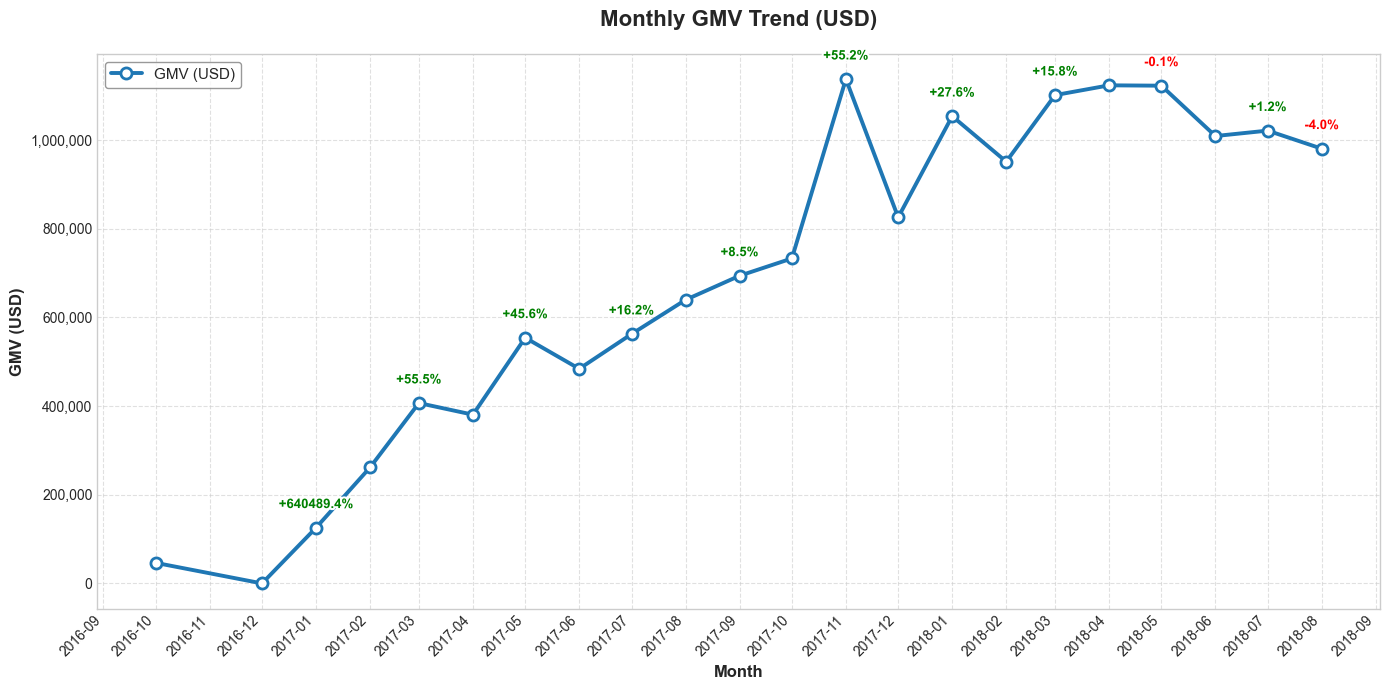

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import matplotlib.patheffects as patheffects

# Đảm bảo datetime
df["order_purchase_date"] = pd.to_datetime(df["order_purchase_date"])

# Tạo cột month (datetime để plot mượt)
df["month"] = df["order_purchase_date"].dt.to_period("M").dt.to_timestamp()

# ────────────────────────────────────────────────
# ✅ TÍNH GMV = price + freight_value
# ────────────────────────────────────────────────
df["gmv_item"] = df["price"] + df["freight_value"]

monthly_gmv = (
    df.groupby("month")["gmv_item"]
      .sum()
      .reset_index(name="gmv_usd")
)

# Tính % tăng trưởng MoM
monthly_gmv["growth_mom"] = monthly_gmv["gmv_usd"].pct_change() * 100

# ────────────────────────────────────────────────
# Plot biểu đồ
# ────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    monthly_gmv["month"],
    monthly_gmv["gmv_usd"],
    color="#1f77b4",
    linewidth=2.8,
    marker="o",
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    label="GMV (USD)"
)

# Format trục Y
def format_number(x, pos):
    return f"{x:,.0f}"

ax.yaxis.set_major_formatter(FuncFormatter(format_number))
ax.set_ylabel("GMV (USD)", fontsize=12, fontweight="bold")

# Format trục X
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right", fontsize=10)

# Thêm nhãn % MoM
for i in range(1, len(monthly_gmv)):
    if i % 2 == 0 or i == len(monthly_gmv) - 1:
        growth = monthly_gmv["growth_mom"].iloc[i]
        y_pos = monthly_gmv["gmv_usd"].iloc[i]
        color = "green" if growth >= 0 else "red"
        
        ax.annotate(
            f"{growth:+.1f}%",
            xy=(monthly_gmv["month"].iloc[i], y_pos),
            xytext=(0, 12),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9.5,
            fontweight="bold",
            color=color,
            path_effects=[patheffects.withStroke(linewidth=3, foreground="white")]
        )

ax.set_title("Monthly GMV Trend (USD)", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Month", fontsize=12, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="upper left", fontsize=11, frameon=True, edgecolor="gray")

plt.tight_layout()
plt.show()


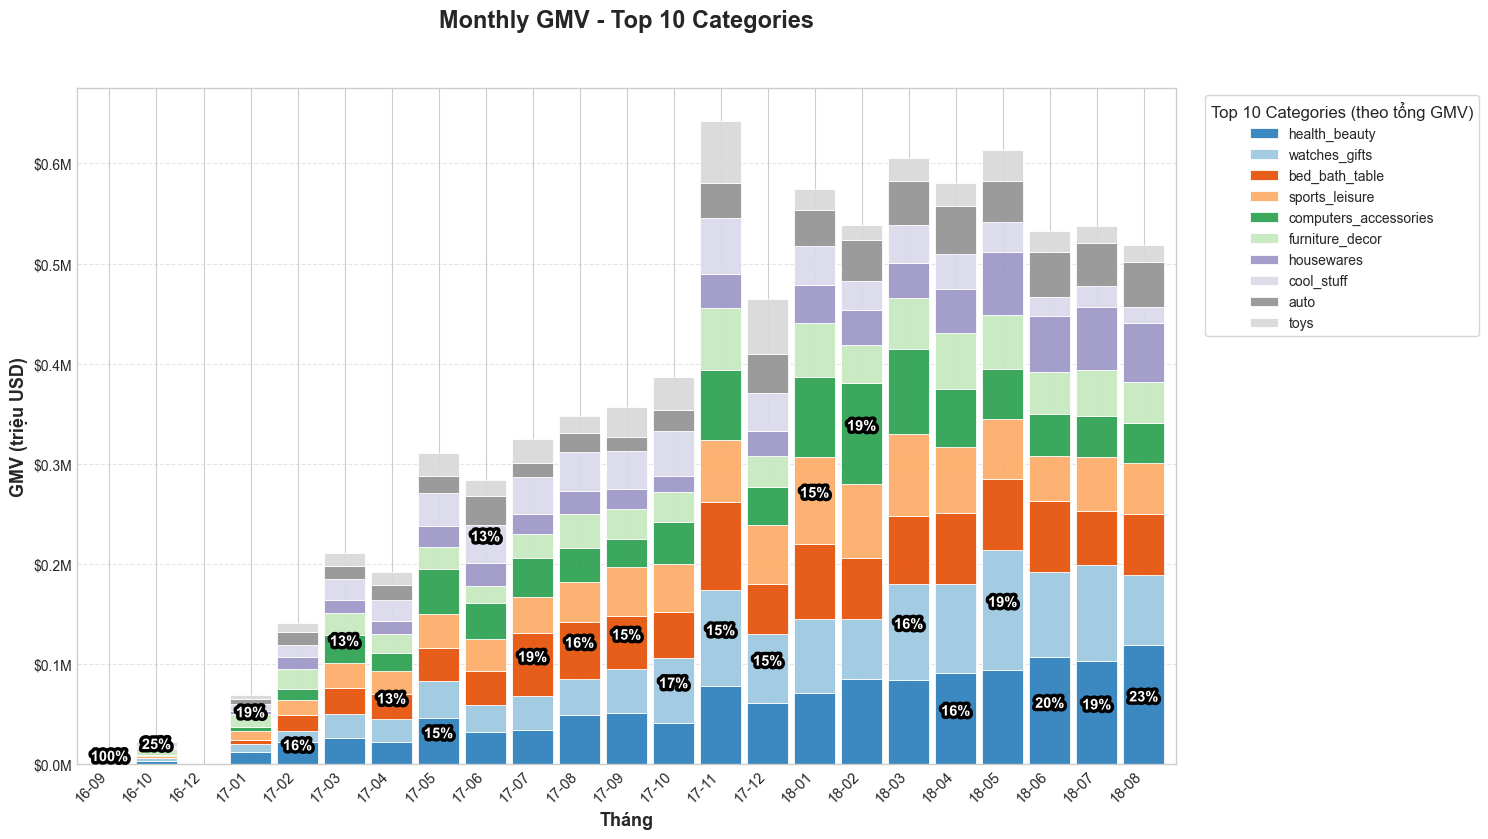

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
from matplotlib.ticker import FuncFormatter

# ────────────────────────────────────────────────
# Chuẩn bị dữ liệu
# ────────────────────────────────────────────────
df["order_purchase_date"] = pd.to_datetime(df["order_purchase_date"], errors='coerce')
df = df.dropna(subset=["order_purchase_date"])

df["month"] = df["order_purchase_date"].dt.to_period("M").dt.to_timestamp()

monthly_cat = df.groupby(["month", "product_category_name_english"])["price"].sum().unstack(fill_value=0)

total_gmv_per_cat = monthly_cat.sum().sort_values(ascending=False)

top_n = 10
top_categories = total_gmv_per_cat.head(top_n).index.tolist()

monthly_cat_top = monthly_cat[top_categories].copy()
monthly_cat_top = monthly_cat_top[total_gmv_per_cat[top_categories].index]

# Tính tổng và phần trăm
monthly_total = monthly_cat_top.sum(axis=1)
monthly_pct = monthly_cat_top.div(monthly_total.where(monthly_total > 0, pd.NA), axis=0) * 100
monthly_pct = monthly_pct.fillna(0)

# ────────────────────────────────────────────────
# Vẽ biểu đồ
# ────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")  # comment nếu lỗi style

fig, ax = plt.subplots(figsize=(15, 8.5))

monthly_cat_top.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="tab20c",
    width=0.88,
    edgecolor="white",
    linewidth=0.6,
    alpha=0.95
)

def millions(x, pos):
    return f"${x/1e6:,.1f}M"

ax.yaxis.set_major_formatter(FuncFormatter(millions))
ax.set_ylabel("GMV (triệu USD)", fontsize=13, fontweight="bold")

ax.set_xlabel("Tháng", fontsize=13, fontweight="bold")
ax.set_xticklabels(
    [m.strftime("%y-%m") for m in monthly_cat_top.index],
    rotation=45,
    ha="right",
    fontsize=10.5
)

# ────────────────────────────────────────────────
# THÊM LABEL % CHO TẤT CẢ CÁC THÁNG (category lớn nhất)
# ────────────────────────────────────────────────
for i, month in enumerate(monthly_cat_top.index):
    if monthly_total.get(month, 0) <= 0:
        continue

    pct_this_month = monthly_pct.loc[month].dropna()
    
    if pct_this_month.empty:
        continue

    max_pct = pct_this_month.max()
    max_cat = pct_this_month.idxmax()

    # Tính vị trí y ở giữa thanh stack
    col_idx = monthly_cat_top.columns.get_loc(max_cat)
    prev_cols = monthly_cat_top.columns[:col_idx]
    cumsum_prev = monthly_cat_top.loc[month, prev_cols].sum() if len(prev_cols) > 0 else 0
    bar_height = monthly_cat_top.loc[month, max_cat]
    y_center = cumsum_prev + bar_height / 2

    # Hiển thị %
    ax.text(
        i, y_center,
        f"{int(round(max_pct))}%\n",
        ha="center",
        va="center",
        fontsize=10.5,              # hơi nhỏ lại để tránh chồng chéo nếu nhiều tháng
        fontweight="bold",
        color="white",
        path_effects=[patheffects.withStroke(linewidth=5, foreground="black")],
        linespacing=1.0
    )

# ────────────────────────────────────────────────
# Tiêu đề, legend, grid
# ────────────────────────────────────────────────
ax.set_title(
    f"Monthly GMV - Top {top_n} Categories\n",
    fontsize=17,
    fontweight="bold",
    pad=25
)

ax.legend(
    title=f"Top {top_n} Categories (theo tổng GMV)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10,
    title_fontsize=12,
    frameon=True,
    edgecolor="#cccccc",
    ncol=1
)

ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
gmv_total = df.groupby("customer_type")["price"].sum()
gmv_total

customer_type
New    12936872.19
Old      284625.92
Name: price, dtype: float64

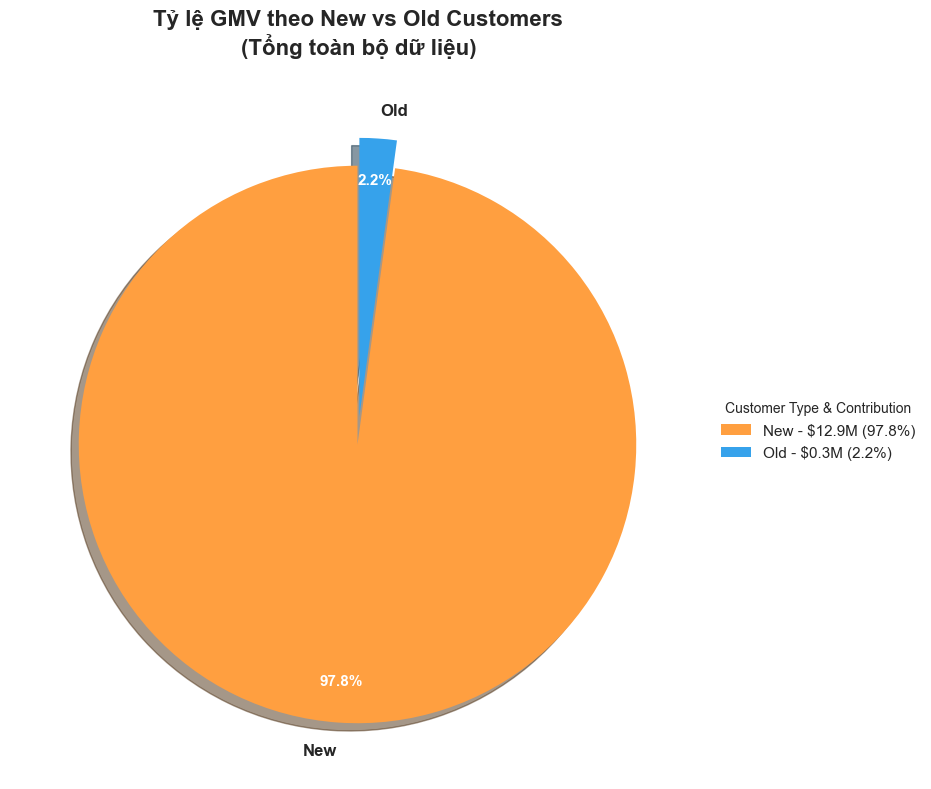

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Giả sử bạn đã có df với cột 'customer_type' (New/Repeat) và 'price' (GMV)
# Nếu chưa có, chạy lại phần merge first_purchase từ code trước đó

# Tính tổng GMV theo type
gmv_total = df.groupby("customer_type")["price"].sum()

# Tính phần trăm
percentages = gmv_total / gmv_total.sum() * 100

# ────────────────────────────────────────────────
# Vẽ Pie Chart đẹp
# ────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-pastel")  # màu nhẹ, đẹp

fig, ax = plt.subplots(figsize=(10, 8))

# Màu: New = cam nhạt, Repeat = xanh dương
colors = ["#ff9f40", "#36a2eb"] if len(gmv_total) == 2 else plt.cm.Pastel1(range(len(gmv_total)))

wedges, texts, autotexts = ax.pie(
    gmv_total,
    labels=gmv_total.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85,
    explode=[0.05] * len(gmv_total),  # tách nhẹ từng miếng
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Thêm giá trị tuyệt đối (triệu USD) vào legend hoặc bên ngoài
legend_labels = [f"{label} - ${value/1e6:,.1f}M ({percent:.1f}%)" 
                 for label, value, percent in zip(gmv_total.index, gmv_total, percentages)]

ax.legend(wedges, legend_labels, 
          title="Customer Type & Contribution",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1),
          fontsize=11)

# Tiêu đề
ax.set_title("Tỷ lệ GMV theo New vs  Customers\n(Tổng toàn bộ dữ liệu)", 
             fontsize=16, fontweight="bold", pad=20)

# Làm tròn và đẹp hơn
plt.setp(autotexts, size=11, weight="bold", color="white")

plt.tight_layout()
plt.show()

#installment

C:\Users\TFS-MT-051\AppData\Local\Temp\ipykernel_80172\1295816409.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly = df.groupby("month").apply(


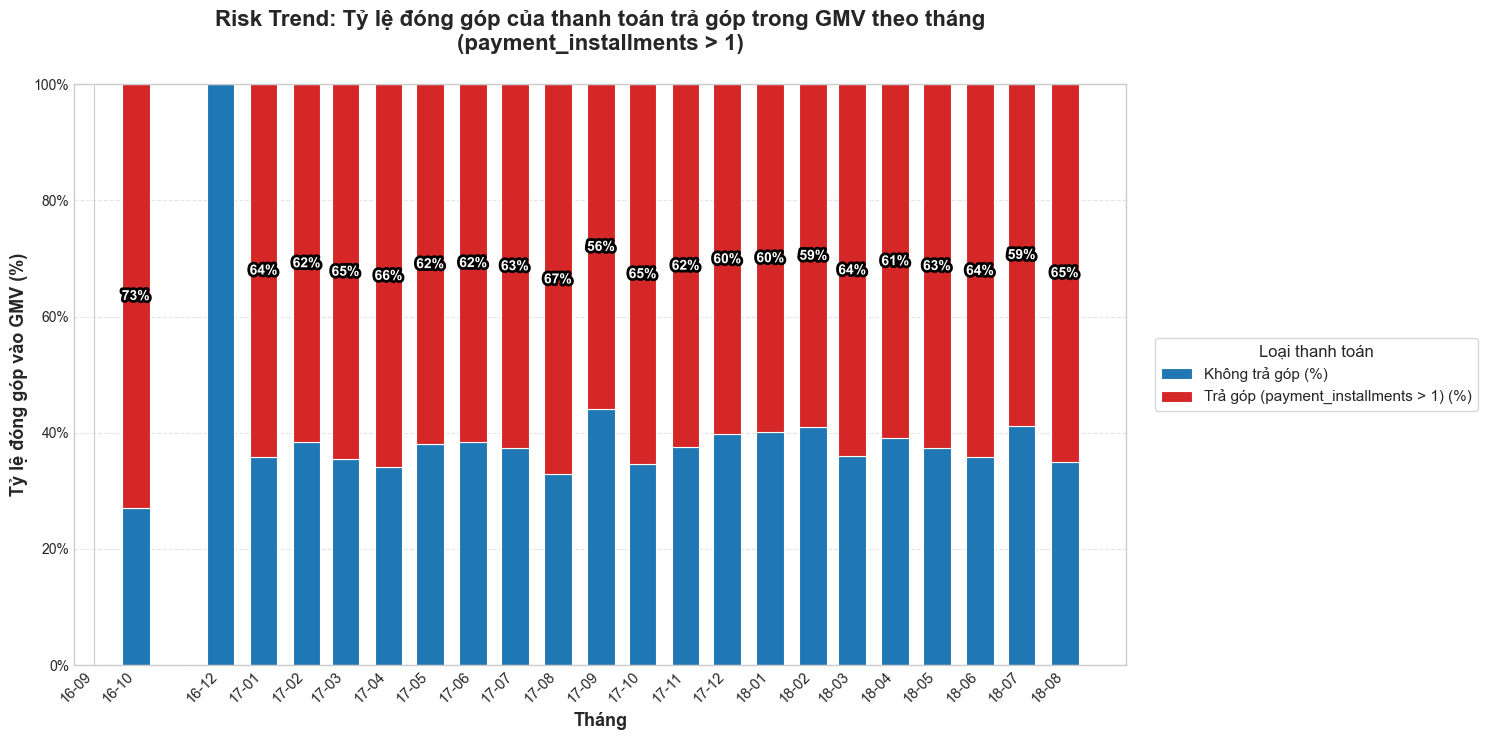

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.patheffects as patheffects  # Import đúng

# ────────────────────────────────────────────────
# 1. Chuẩn bị dữ liệu
# ────────────────────────────────────────────────
df["order_purchase_date"] = pd.to_datetime(df["order_purchase_date"], errors='coerce')
df = df.dropna(subset=["order_purchase_date"])

df["month"] = df["order_purchase_date"].dt.to_period("M").dt.to_timestamp()

# Tính GMV theo tháng và theo loại thanh toán
monthly = df.groupby("month").apply(
    lambda g: pd.Series({
        "Non_Installment": g[g["payment_installments"] <= 1]["payment_value"].sum(),
        "Installment": g[g["payment_installments"] > 1]["payment_value"].sum()
    })
).reset_index()

monthly["Total_GMV"] = monthly["Non_Installment"] + monthly["Installment"]
monthly["Non_Installment_pct"] = (monthly["Non_Installment"] / monthly["Total_GMV"]) * 100
monthly["Installment_pct"] = (monthly["Installment"] / monthly["Total_GMV"]) * 100

monthly = monthly.sort_values("month").reset_index(drop=True)

# ────────────────────────────────────────────────
# 2. Vẽ 100% Stacked Bar Chart
# ────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(15, 7.5))

ax.bar(
    monthly["month"],
    monthly["Non_Installment_pct"],
    label="Không trả góp (%)",
    color="#1f77b4",
    width=20,
    edgecolor="white",
    linewidth=0.8
)

ax.bar(
    monthly["month"],
    monthly["Installment_pct"],
    bottom=monthly["Non_Installment_pct"],
    label="Trả góp (payment_installments > 1) (%)",
    color="#d62728",
    width=20,
    edgecolor="white",
    linewidth=0.8
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_ylabel("Tỷ lệ đóng góp vào GMV (%)", fontsize=13, fontweight="bold")
ax.set_ylim(0, 100)

ax.set_xlabel("Tháng", fontsize=13, fontweight="bold")
ax.set_xticks(monthly["month"])
ax.set_xticklabels([m.strftime("%y-%m") for m in monthly["month"]], rotation=45, ha="right", fontsize=10.5)

# Thêm nhãn % trả góp (đã sửa path_effects)
for i, row in monthly.iterrows():
    if row["Installment_pct"] >= 10:
        ax.text(
            row["month"],
            row["Non_Installment_pct"] + row["Installment_pct"] / 2,
            f"{row['Installment_pct']:.0f}%",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="white",
            path_effects=[patheffects.withStroke(linewidth=4, foreground="black")]  # ← SỬA Ở ĐÂY
        )

ax.legend(
    title="Loại thanh toán",
    loc="center left",                  # vị trí anchor tương đối
    bbox_to_anchor=(1.02, 0.5),         # đẩy ra ngoài bên phải, giữa chiều cao
    fontsize=11,
    title_fontsize=12,
    frameon=True,
    edgecolor="#cccccc",
    ncol=1                              # 1 cột để dễ đọc
)
ax.set_title(
    "Risk Trend: Tỷ lệ đóng góp của thanh toán trả góp trong GMV theo tháng\n"
    "(payment_installments > 1)",
    fontsize=16,
    fontweight="bold",
    pad=25
)

ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\TFS-MT-051\AppData\Local\Temp\ipykernel_80172\2724349231.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_stats = df.groupby('price_bucket').agg(


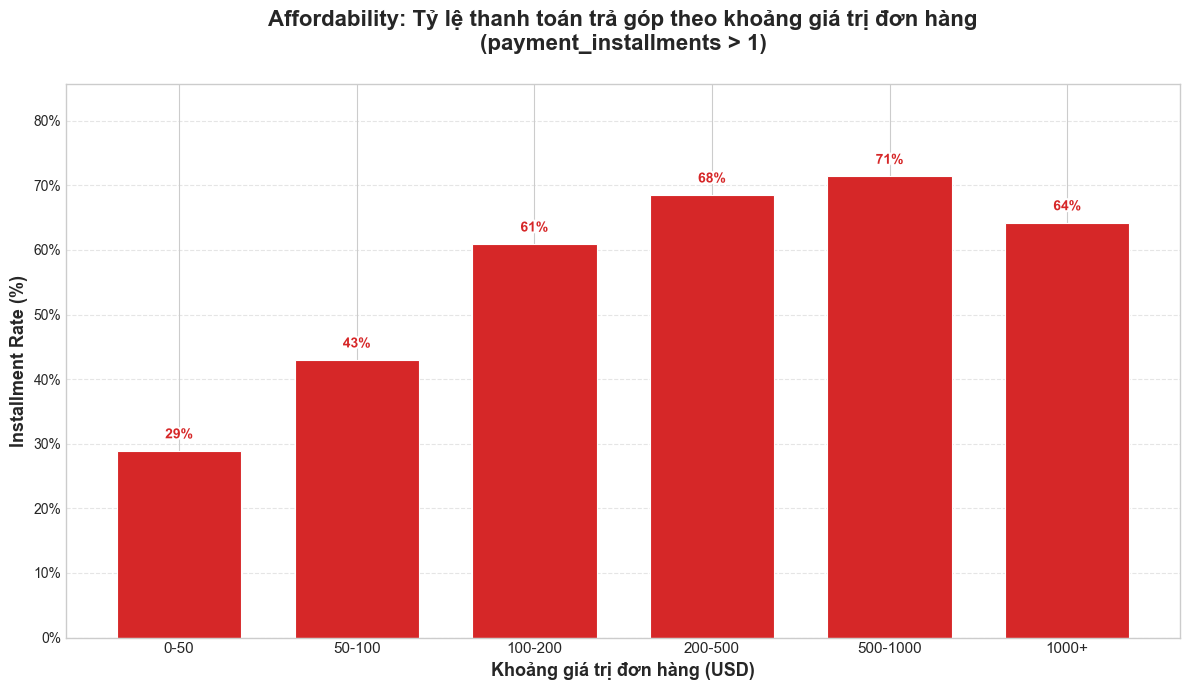

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.patheffects as patheffects

# ────────────────────────────────────────────────
# 1. Chuẩn bị dữ liệu
# ────────────────────────────────────────────────
# Đảm bảo datetime và loại bỏ giá trị thiếu
df["order_purchase_date"] = pd.to_datetime(df["order_purchase_date"], errors='coerce')
df = df.dropna(subset=["order_purchase_date", "payment_value", "payment_installments"])

# Tạo Price Bucket (các khoảng giá, bạn có thể chỉnh khoảng tùy dữ liệu)
bins = [0, 50, 100, 200, 500, 1000, float('inf')]
labels = ['0-50', '50-100', '100-200', '200-500', '500-1000', '1000+']
df['price_bucket'] = pd.cut(df['payment_value'], bins=bins, labels=labels, right=False)

# Tính tổng giá trị và giá trị trả góp theo bucket
bucket_stats = df.groupby('price_bucket').agg(
    Total_Value=('payment_value', 'sum'),
    Installment_Value=('payment_value', lambda x: x[df.loc[x.index, 'payment_installments'] > 1].sum())
).reset_index()

# Tính Installment Rate (%)
bucket_stats['Installment_Rate'] = (bucket_stats['Installment_Value'] / bucket_stats['Total_Value'].replace(0, pd.NA)) * 100
bucket_stats['Installment_Rate'] = bucket_stats['Installment_Rate'].fillna(0)

# Sắp xếp theo thứ tự bucket
bucket_stats = bucket_stats.sort_values('price_bucket')

# ────────────────────────────────────────────────
# 2. Vẽ Column Chart
# ────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(12, 7))

# Vẽ cột
bars = ax.bar(
    bucket_stats['price_bucket'],
    bucket_stats['Installment_Rate'],
    color="#d62728",  # đỏ để nhấn mạnh trả góp
    edgecolor="white",
    linewidth=0.8,
    width=0.7
)

# Format Y-axis: %
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_ylabel("Installment Rate (%)", fontsize=13, fontweight="bold")
ax.set_ylim(0, bucket_stats['Installment_Rate'].max() * 1.2 or 100)

# X-axis: Price Bucket
ax.set_xlabel("Khoảng giá trị đơn hàng (USD)", fontsize=13, fontweight="bold")
ax.tick_params(axis='x', labelsize=11, rotation=0)

# Thêm nhãn % lên đầu mỗi cột
for bar in bars:
    height = bar.get_height()
    if height >= 5:  # chỉ hiện nhãn nếu >=5% để tránh rối
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1.5,
            f"{height:.0f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color="#d62728",
            path_effects=[patheffects.withStroke(linewidth=3, foreground="white")]
        )

# Tiêu đề & grid
ax.set_title(
    "Affordability: Tỷ lệ thanh toán trả góp theo khoảng giá trị đơn hàng\n"
    "(payment_installments > 1)",
    fontsize=16,
    fontweight="bold",
    pad=25
)

ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

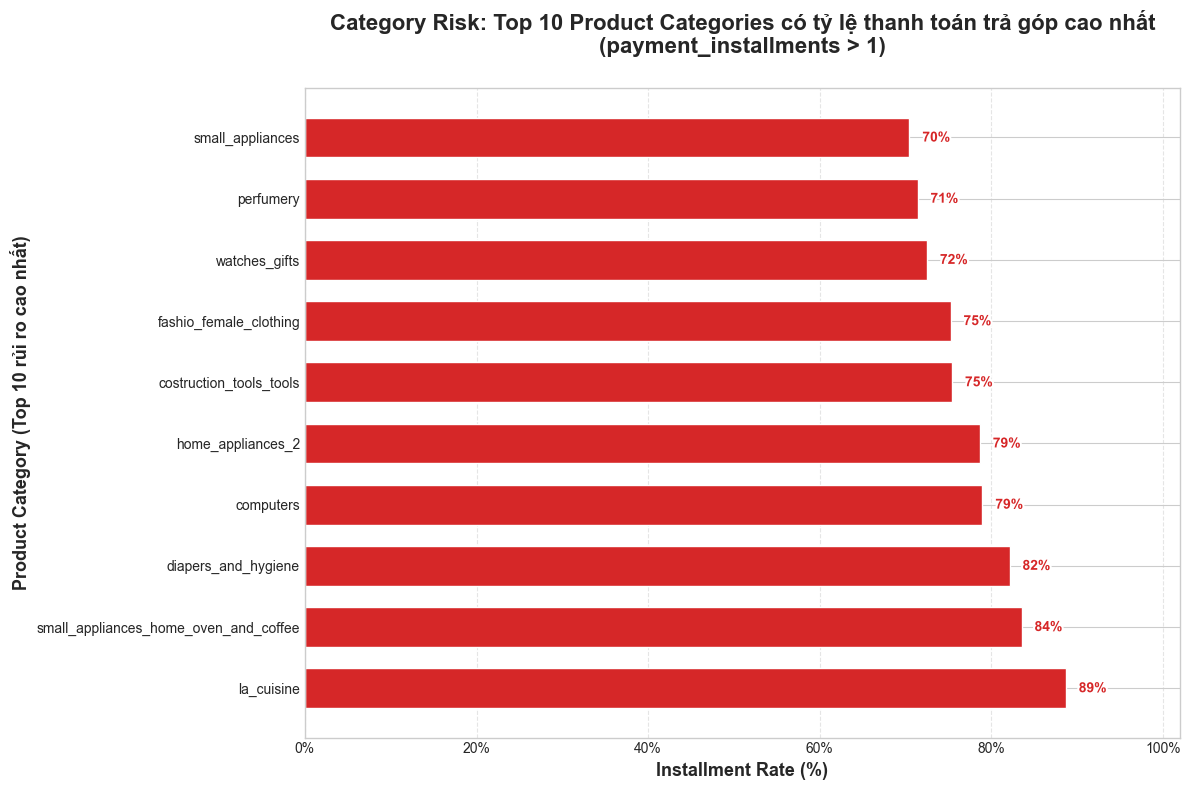

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.patheffects as patheffects

# ────────────────────────────────────────────────
# 1. Chuẩn bị dữ liệu
# ────────────────────────────────────────────────
df["order_purchase_date"] = pd.to_datetime(df["order_purchase_date"], errors='coerce')
df = df.dropna(subset=["order_purchase_date", "payment_value", "payment_installments", "product_category_name_english"])

# Tính tổng giá trị và giá trị trả góp theo category
category_stats = df.groupby("product_category_name_english").agg(
    Total_Value=("payment_value", "sum"),
    Installment_Value=("payment_value", lambda x: x[df.loc[x.index, "payment_installments"] > 1].sum())
).reset_index()

# Tính Installment Rate (%)
category_stats["Installment_Rate"] = (category_stats["Installment_Value"] / category_stats["Total_Value"].replace(0, pd.NA)) * 100
category_stats["Installment_Rate"] = category_stats["Installment_Rate"].fillna(0)

# Sắp xếp giảm dần theo Installment Rate → top 10 rủi ro cao nhất
category_stats = category_stats.sort_values("Installment_Rate", ascending=False).head(10)

# ────────────────────────────────────────────────
# 2. Vẽ Horizontal Bar Chart - Top 10
# ────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(12, 8))  # cao vừa đủ cho 10 category

# Vẽ thanh ngang (top rủi ro cao ở trên)
bars = ax.barh(
    category_stats["product_category_name_english"],
    category_stats["Installment_Rate"],
    color="#d62728",
    edgecolor="white",
    height=0.65
)

# Format X-axis: %
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("Installment Rate (%)", fontsize=13, fontweight="bold")
ax.set_xlim(0, category_stats["Installment_Rate"].max() * 1.15 or 100)

# Y-axis: Category
ax.set_ylabel("Product Category (Top 10 rủi ro cao nhất)", fontsize=13, fontweight="bold")
ax.tick_params(axis='y', labelsize=10)

# Thêm nhãn % lên đầu mỗi thanh
for bar in bars:
    width = bar.get_width()
    if width >= 5:
        ax.text(
            width + 1.5,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.0f}%",
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#d62728",
            path_effects=[patheffects.withStroke(linewidth=3, foreground="white")]
        )

# Tiêu đề & grid
ax.set_title(
    "Category Risk: Top 10 Product Categories có tỷ lệ thanh toán trả góp cao nhất\n"
    "(payment_installments > 1)",
    fontsize=16,
    fontweight="bold",
    pad=25
)

ax.grid(axis="x", linestyle="--", alpha=0.5)

# Legend nhỏ (nếu cần) hoặc bỏ nếu không cần
# ax.legend().set_visible(False)  # nếu muốn ẩn legend

plt.tight_layout()
plt.show()

#quality

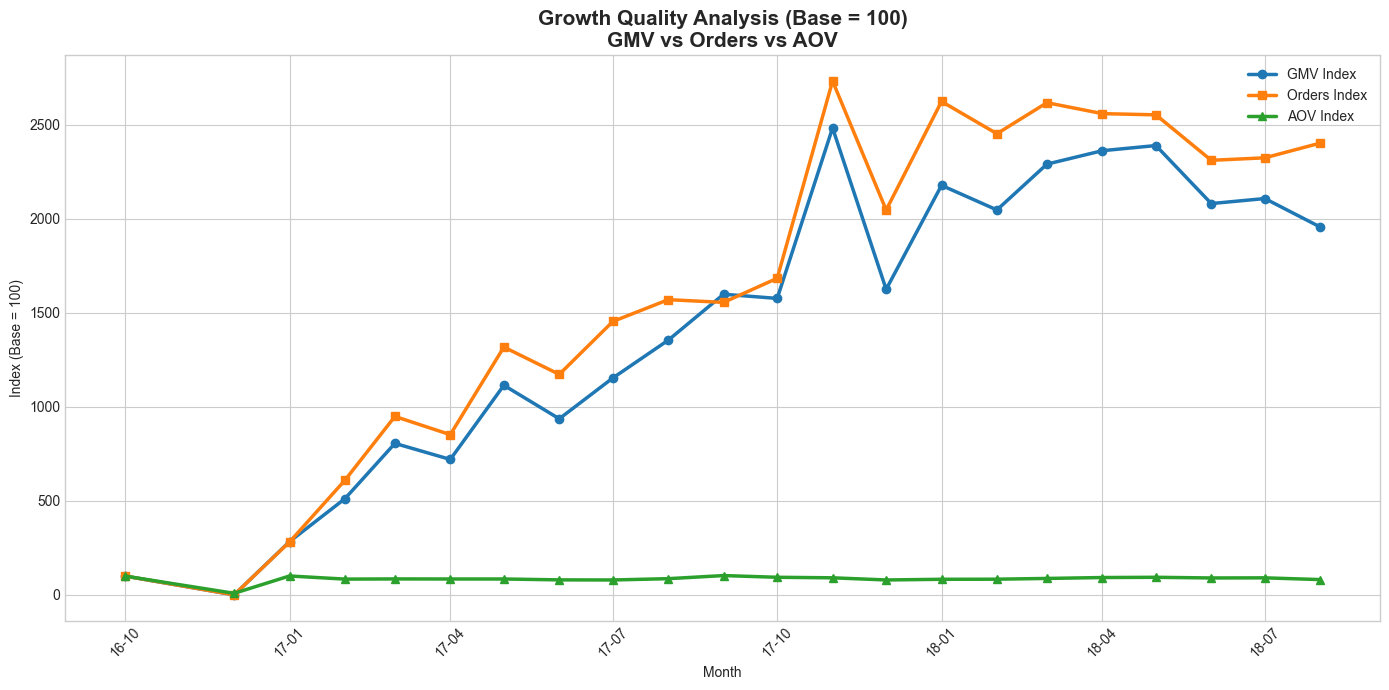

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ────────────────────────────────────────────────
# 1. Chuẩn bị dữ liệu
# ────────────────────────────────────────────────

df["order_purchase_date"] = pd.to_datetime(df["order_purchase_date"], errors="coerce")
df = df.dropna(subset=["order_purchase_date"])

df["month"] = df["order_purchase_date"].dt.to_period("M").dt.to_timestamp()

monthly = df.groupby("month").agg(
    GMV=("payment_value", "sum"),
    Orders=("order_id", "nunique")
).reset_index()

monthly = monthly.sort_values("month").reset_index(drop=True)

# Tính AOV
monthly["AOV"] = monthly["GMV"] / monthly["Orders"]

# ────────────────────────────────────────────────
# 2. Convert về Base 100
# ────────────────────────────────────────────────

monthly["GMV_Index"] = monthly["GMV"] / monthly["GMV"].iloc[0] * 100
monthly["Orders_Index"] = monthly["Orders"] / monthly["Orders"].iloc[0] * 100
monthly["AOV_Index"] = monthly["AOV"] / monthly["AOV"].iloc[0] * 100

# ────────────────────────────────────────────────
# 3. Vẽ chart
# ────────────────────────────────────────────────

plt.figure(figsize=(14, 7))

plt.plot(monthly["month"], monthly["GMV_Index"], marker="o", linewidth=2.5)
plt.plot(monthly["month"], monthly["Orders_Index"], marker="s", linewidth=2.5)
plt.plot(monthly["month"], monthly["AOV_Index"], marker="^", linewidth=2.5)

plt.title("Growth Quality Analysis (Base = 100)\nGMV vs Orders vs AOV",
          fontsize=15, fontweight="bold")

plt.ylabel("Index (Base = 100)")
plt.xlabel("Month")

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%y-%m"))

plt.legend(["GMV Index", "Orders Index", "AOV Index"])
plt.grid(True)

plt.tight_layout()
plt.show()


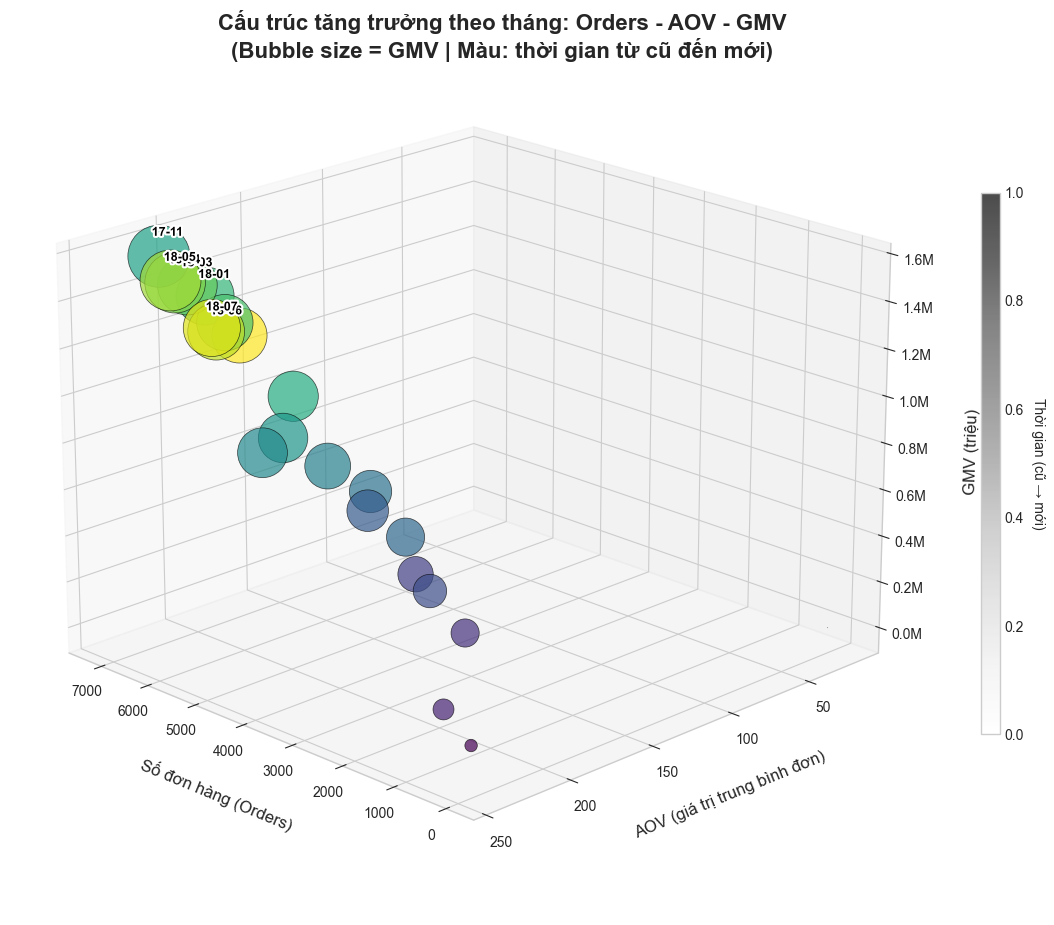

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import FuncFormatter
import matplotlib.cm as cm
import numpy as np

# ────────────────────────────────────────────────
# 1. Chuẩn bị dữ liệu
# ────────────────────────────────────────────────
df["order_purchase_date"] = pd.to_datetime(df["order_purchase_date"], errors='coerce')
df = df.dropna(subset=["order_purchase_date", "payment_value"])

df["month"] = df["order_purchase_date"].dt.to_period("M").dt.to_timestamp()

# Tính Orders, GMV, AOV theo tháng
monthly = df.groupby("month").agg(
    Orders=("order_id", "nunique"),              # Số đơn hàng duy nhất
    GMV=("payment_value", "sum")                 # Tổng GMV
).reset_index()

monthly["AOV"] = monthly["GMV"] / monthly["Orders"].replace(0, pd.NA)
monthly["AOV"] = monthly["AOV"].fillna(0)

# Sắp xếp theo thời gian
monthly = monthly.sort_values("month").reset_index(drop=True)

# Tạo số thứ tự tháng để làm màu gradient
monthly["month_num"] = range(len(monthly))

# ────────────────────────────────────────────────
# 2. Vẽ Bubble Chart 3D
# ────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Scale bubble size (GMV) để vừa mắt
bubble_size = monthly["GMV"] / monthly["GMV"].max() * 2000  # max size ~2000 điểm

# Màu gradient theo thời gian (cũ → mới: xanh dương → đỏ)
colors = cm.viridis(np.linspace(0, 1, len(monthly)))  # hoặc cm.plasma, cm.inferno

scatter = ax.scatter(
    monthly["Orders"],
    monthly["AOV"],
    monthly["GMV"] / 1e6,               # trục Z: GMV (triệu)
    s=bubble_size,
    c=colors,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5
)

# Format trục
def millions_z(x, pos):
    return f"{x:.1f}M"
ax.zaxis.set_major_formatter(FuncFormatter(millions_z))

ax.set_xlabel("Số đơn hàng (Orders)", fontsize=12, labelpad=15)
ax.set_ylabel("AOV (giá trị trung bình đơn)", fontsize=12, labelpad=15)
ax.set_zlabel("GMV (triệu)", fontsize=12, labelpad=15)

# Thêm nhãn tháng cho các bubble lớn
for i, row in monthly.iterrows():
    if row["GMV"] >= monthly["GMV"].quantile(0.7):  # chỉ nhãn cho tháng lớn (top 30%)
        ax.text(
            row["Orders"] * 1.02,
            row["AOV"],
            row["GMV"] / 1e6 * 1.05,
            row["month"].strftime("%y-%m"),
            fontsize=9,
            color="black",
            fontweight="bold",
            path_effects=[patheffects.withStroke(linewidth=3, foreground="white")]
        )

# Thêm colorbar để giải thích gradient thời gian
cbar = fig.colorbar(scatter, ax=ax, shrink=0.6, aspect=30)
cbar.set_label("Thời gian (cũ → mới)", rotation=270, labelpad=15)

# Tiêu đề
fig.suptitle(
    "Cấu trúc tăng trưởng theo tháng: Orders - AOV - GMV\n"
    "(Bubble size = GMV | Màu: thời gian từ cũ đến mới)",
    fontsize=16,
    fontweight="bold",
    y=0.92
)

# Xoay góc nhìn đẹp hơn
ax.view_init(elev=20, azim=135)

plt.tight_layout()
plt.show()